In [1]:
import sys
import os
import numpy as np 
import torch

# Set PROJECT ROOT (folder that contains "src/")
PROJECT_ROOT = os.path.abspath("..")   # or the exact path
sys.path.insert(0, PROJECT_ROOT)

from src.utils import QubitOperatorTorch, Haar_unitary_gate, iregroup, irescale

ImportError: cannot import name 'Haar_unitary_gate' from 'src.utils' (/home/vanregem/projects/lsip_Q_ONE/MPDO_circuit/src/utils.py)

In [13]:
import torch

L = 1000
shape = [100, 20, 3, 20]

set = [torch.rand(*shape, device='cuda:3', dtype=torch.complex128) for _ in range(L)]

print(torch.sum(torch.tensor([torch.cuda.memory_allocated('cuda:3') for t in set])) / 1024 ** 3)

tensor(1788.1394)


In [4]:
d = {'a': 2, 'b':3}
a = d.pop('a')
print(a)
print(d)


2
{'b': 3}


In [33]:
def Haar_unitary_gate(num_modes:int=2, Nmax: int=2, device='cpu'):

    """
    Return an n x n random unitary matrix drawn from the Haar measure.
    Method: make a random (complex) Ginibre matrix Z, do QR, then remove
    the phases of R's diagonal by multiplying columns of Q by conj(diag(R)/|diag(R)|).
    """

    # matrix dimension
    n = Nmax ** num_modes

    # real + i * imag Gaussian entries
    real = torch.randn((n, n), dtype=torch.float64, device=device)
    imag = torch.randn((n, n), dtype=torch.float64, device=device)
    Z = (real + 1j * imag).to(torch.complex128)

    # QR decomposition
    Q, R = torch.linalg.qr(Z)

    # Extract diagonal of R and compute phase factors
    diagR = torch.diagonal(R, 0)
    # avoid division by zero just in case (extremely unlikely for continuous Gaussians)
    eps = torch.finfo(diagR.real.dtype).tiny
    phases = diagR / (torch.abs(diagR) + eps)  
    # Multiply each column i of Q by conj(phases[i]) to fix R diagonals to be positive real
    Q = Q * phases.conj().unsqueeze(0)           # broadcast across rows

    # return in tensor format. Don't forget to place indices in right order
    shape = [Nmax] * (2 * num_modes)
    index_order = list(range(num_modes)) + list(range(2*num_modes-1,num_modes-1,-1))
    return Q.view(*shape).permute(index_order)

U = Haar_unitary_gate(num_modes=3, Nmax=3)


In [35]:
U.shape

torch.Size([3, 3, 3, 3, 3, 3])

In [34]:
id = torch.einsum('ijkl, mnkl->ijnm', U, U.conj())

id.permute(0,1,3,2).reshape(4,4)[0]

RuntimeError: einsum(): the number of subscripts in the equation (4) does not match the number of dimensions (6) for operand 0 and no ellipsis was given

In [2]:
Mc = lambda k: 1.6114 + 0.037 * k  # (photonic mode approximated as a straight line)
Exca = 1.6229  # (exciton energy)
OM = 3.4 * 1e-3 # (half the Rabi splitting)
hbar_eV_ps = 6.582 * 1e-4 # hbar, converting energy to frequency

def omega_LP(k:float):
    """
    Lower-polariton dispersion in eV and um!

    """

    LP_disp =  0.5 * (Mc(k) + Exca) - 0.5 * ((Mc(k) - Exca)**2 + 4. * OM ** 2) ** 0.5
    return LP_disp


def vg_LP(k: float, dk: float=1e-3):
    return (omega_LP(k + dk/2.) - omega_LP(k - dk/2.)) / dk / hbar_eV_ps


def exciton_fraction(k):
    theta_k = np.arctan(OM / (omega_LP(k) - Mc(k)))
    return np.cos(theta_k) ** 2


Text(0.5, 1.0, 'exciton fraction')

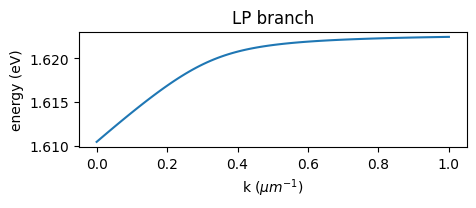

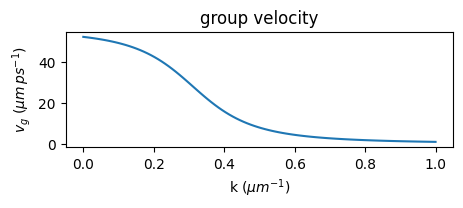

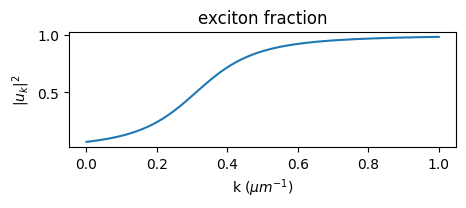

In [3]:
import numpy as np
import matplotlib.pyplot as plt 

k = np.linspace(0., 1, 100)

plt.figure(figsize=(5,1.5))
plt.plot(k, omega_LP(k))
plt.xlabel(r"k ($\mu m^{-1}$)")
plt.ylabel(r"energy (eV)")
plt.title("LP branch")

plt.figure(figsize=(5,1.5))
plt.plot(k, vg_LP(k))
plt.xlabel(r"k ($\mu m^{-1}$)")
plt.ylabel(r"$v_g$ ($\mu m\, ps^{-1}$)")
plt.title("group velocity")

plt.figure(figsize=(5,1.5))
plt.plot(k, exciton_fraction(k))
plt.xlabel(r"k ($\mu m^{-1}$)")
plt.ylabel(r"$|u_k|^2$")
plt.title("exciton fraction")

In [14]:
import torch 
from time import time

start = time()
M = torch.rand(5, 1000000)
U, s, Vd = torch.svd_lowrank(M, q=5)
print(f"time={time()-start:.4f}s")
print(s)

time=0.1927s
tensor([1154.6499,  289.0150,  288.8962,  288.6474,  288.4307])


In [17]:
K_concat.shape

torch.Size([6, 2])

In [ ]:
b = 32
d = 2
D = 500
device = 'cuda:0'

K_ops = [torch.rand(d, d, device=device) for _ in range(3)]
K_concat = torch.stack(K_ops)

B = torch.rand(b,D,d,D, device=device)


start = time()
Kp = torch.concat([
                torch.einsum("ij, bkjm -> bkim", K, B) for K in K_ops
            ], dim=0) if len(K_ops) > 0 else B
print(f"t={time()-start:.4f}")

start = time()
Kp_concat = torch.einsum("aij, bkjm -> abkim", K_concat, B)
Kp_concat = Kp_concat.reshape(K_concat.shape[0] * B.shape[0], *Kp_concat.shape[2:])
print(f"t={time()-start:.4f}")

t=0.0012
t=0.0007


In [ ]:
start = time()
Kp_svd = torch.svd(Kp.reshape(Kp.shape[0],-1))
print(f"t={time()-start:.4f}")

q = 100
start = time()
Kp_svd_concat = torch.svd_lowrank(Kp.reshape(Kp.shape[0],-1), q=q,)
print(f"t={time()-start:.4f}")

t=0.1277


t=0.3675


In [ ]:
Kp_svd[1].shape

tensor([3702.4036,  273.4901,  272.9987,  272.9044,  272.8004,  272.3593,
         272.3039,  272.2403,  272.1050,  272.0606,  271.8690,  271.4227,
         271.3180,  271.2487,  271.0051,  270.8723,  270.7375,  270.3704,
         270.2928,  270.2103,  269.9078,  269.8841,  269.5638,  269.3836,
         269.3564,  269.1839,  269.0384,  269.0027,  268.6602,  268.4564,
         268.2156,  268.0938,  211.1589,  122.8611,  122.6568,  122.5305,
         122.4548,  122.4067,  122.3735,  122.3174,  122.2945,  122.1877,
         122.0596,  121.9683,  121.9504,  121.8123,  121.7137,  121.6911,
         121.6467,  121.5499,  121.4762,  121.3718,  121.2827,  121.2155,
         121.1870,  121.0859,  121.0620,  120.9594,  120.9177,  120.8310,
         120.7987,  120.7040,  120.4205,  120.3283,  105.5685,   41.6436,
          41.5733,   41.5411,   41.5175,   41.4866,   41.4697,   41.4484,
          41.4192,   41.3959,   41.3536,   41.3279,   41.3209,   41.3082,
          41.2951,   41.2365,   41.219